In [46]:
import sys
sys.path.append('../src/visualization')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
from tools import print_title

# Estilo visual
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "figure.facecolor" : "white",
    "axes.facecolor" : "white",
    "font.family" : "DejaVu Sans",
    "axes.titlesize" : 14,
    "axes.titleweight" : "bold"
})

# Carga incial de la data
df = pd.read_csv("../data/processed/albums_clean.csv")
df['decade'] = (df['release_date'] // 10) * 10

# Verificación básica del DataFrame
print(f'Forma del DataFrame: {df.shape}')
print(df[['album', 'artist', 'release_date']].sample(3))

Forma del DataFrame: (827, 7)
                                     album        artist  release_date
63                       The Forever Story           JID          2022
714  Sing Me A Lullaby, My Sweet Tempation  $uicide Boy$          2022
702                              BORN PINK     BLACKPINK          2022


                                            TOP 10 ARTISTAS CON MÁS ÁLBUMES                                             


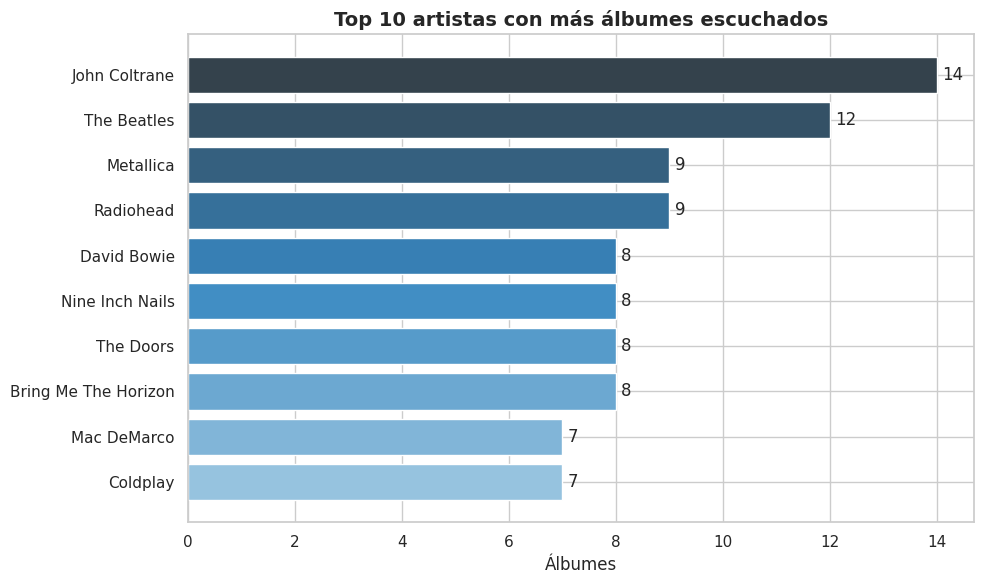

In [33]:
# TOP 10 ARTISTAS CON MÁS ÁLBUMES

print_title('TOP 10 ARTISTAS CON MÁS ÁLBUMES', 120)

top_artist = df['artist'].value_counts().head(10).sort_values()

fig, ax = plt.subplots(figsize=(10,6))
ax.barh(top_artist.index, top_artist.values, color=sns.color_palette('Blues_d', len(top_artist)))
ax.set_xlabel('Álbumes')
ax.set_title('Top 10 artistas con más álbumes escuchados')

for i, v in enumerate(top.values):
    ax.text(v + 0.1, i, str(v), va='center')
    
plt.tight_layout()
plt.savefig('../outputs/figures/top_artists.png', dpi=300, bbox_inches='tight')
plt.show()

                                                   ALBUMES POR DÉCADA                                                   


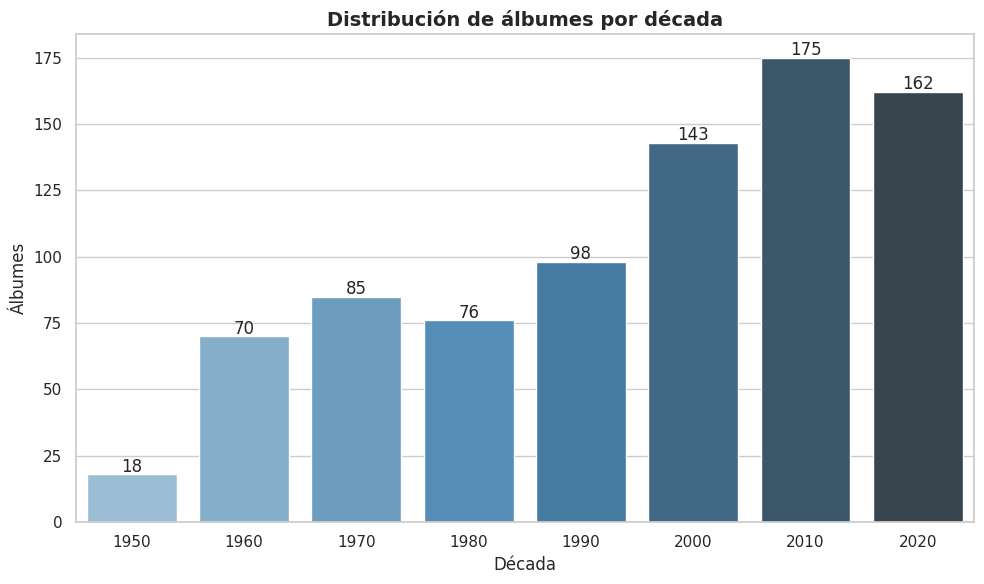

In [34]:
# ALBUMES POR DECADA

print_title('ALBUMES POR DÉCADA', 120)

decade_counts = df.groupby('decade')['album'].count()

fig, ax = plt.subplots(figsize=(10,6))
sns.barplot(x=decade_counts.index, y=decade_counts.values, palette='Blues_d', ax=ax)

ax.set_xlabel('Década')
ax.set_ylabel('Álbumes')
ax.set_title('Distribución de álbumes por década')

for i, v in enumerate(decade_counts.values):
    ax.text(i, v + 1, str(v), ha='center')
    
plt.tight_layout()
plt.savefig('../outputs/figures/albumes_by_decade.png', dpi=300, bbox_inches='tight')
plt.show()

                                               RATING PROMEDIO POR DECADA                                               


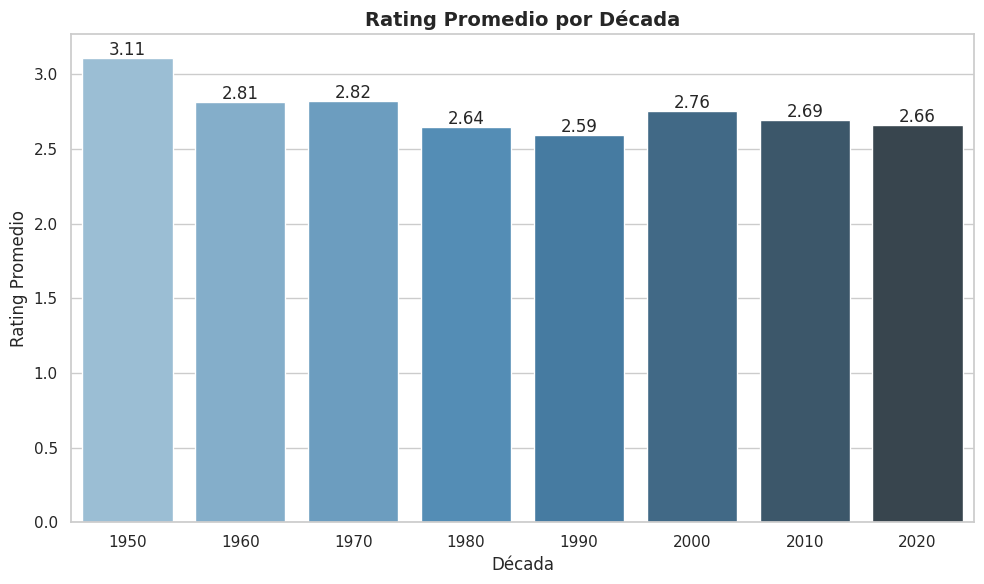

In [42]:
# RATING PROMEDIO POR DECADA

print_title('RATING PROMEDIO POR DECADA', 120)

decade_mean = df.groupby('decade')['rating'].mean()

fig, ax = plt.subplots(figsize=(10,6))
sns.barplot(x=decade_mean.index, y=decade_mean.values, palette='Blues_d', ax=ax)

ax.set_xlabel('Década')
ax.set_ylabel('Rating Promedio')
ax.set_title('Rating Promedio por Década')

for i, v in enumerate(decade_mean.values):
    ax.text(i, v + 0.02, f'{v:.2f}', ha='center')

plt.tight_layout()
plt.savefig('../outputs/figures/rating_mean_decade.png', dpi=300, bbox_inches='tight')
plt.show()

                                            CORRELACION ENTRE SONGS Y RATING                                            


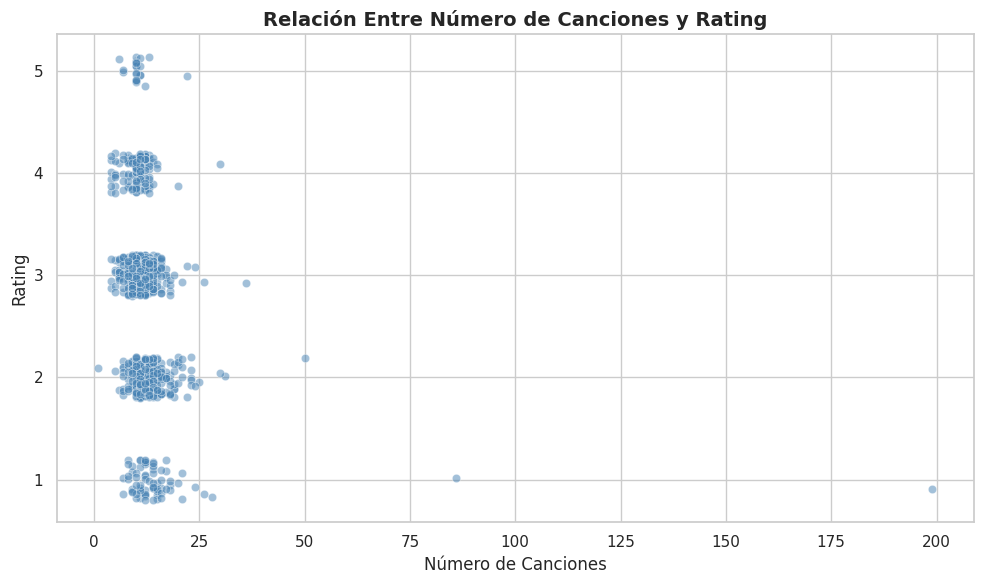

In [48]:
# CORRELACION ENTRE CANCIONES Y CALIFICACION

print_title('CORRELACION ENTRE SONGS Y RATING', 120)

# Aplicación de jitter para evitar superposición de puntos
df['rating_jitter'] = df['rating'] + np.random.uniform(-0.2, 0.2, size=len(df))

fig, ax = plt.subplots(figsize=(10,6))
sns.scatterplot(data=df, x='songs', y='rating_jitter', alpha=0.5, color='steelblue', ax=ax)

ax.set_xlabel('Número de Canciones')
ax.set_ylabel('Rating')
ax.set_title('Relación Entre Número de Canciones y Rating')

plt.tight_layout()
plt.savefig('../outputs/figures/songs_rating_corr.png', dpi=300, bbox_inches='tight')
plt.show()

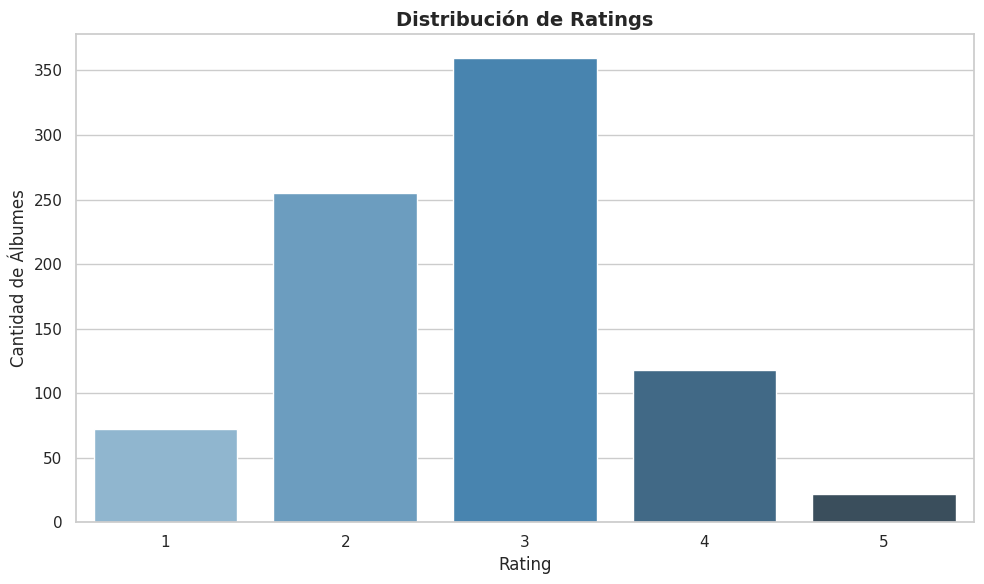

In [49]:
# DISTRIBUCION DE RATINGS

fig, ax = plt.subplots(figsize=(10,6))

sns.countplot(data=df, x='rating', palette='Blues_d', ax=ax)
ax.set_xlabel('Rating')
ax.set_ylabel('Cantidad de Álbumes')
ax.set_title('Distribución de Ratings')

plt.tight_layout()
plt.savefig('../outputs/figures/rating_distribution.png', dpi=300, bbox_inches='tight')
plt.show()